#  K-Means Clustering with Real Sales Data

Creating own dataset inspired from real life problems

In [1]:
# Import pandas for data handling
import pandas as pd

# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Import KMeans from sklearn
from sklearn.cluster import KMeans

---
##  Creating the Sales Dataset



In [2]:
# Create order IDs from 1 to 50
order_ids = list(range(1, 51))

# Print to verify
print("Order IDs created:")
print(order_ids)

# Create purchase amounts
# These represent different spending levels
amounts = [
    100, 200, 150, 400, 350,   # Orders 1-5
    100, 200, 150, 400, 350,   # Orders 6-10
    100, 200, 150, 400, 350,   # Orders 11-15
    100, 200, 150, 400, 350,   # Orders 16-20
    100, 200, 150, 400, 350,   # Orders 21-25
    100, 200, 150, 400, 350,   # Orders 26-30
    100, 200, 150, 400, 350,   # Orders 31-35
    100, 200, 150, 400, 350,   # Orders 36-40
    100, 200, 150, 400, 350,   # Orders 41-45
    100, 200, 150, 400, 350    # Orders 46-50
]

print("\nPurchase amounts created:")
print(amounts)

Order IDs created:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]

Purchase amounts created:
[100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350]


In [3]:
# Create product categories
# We repeat the pattern 10 times to get 50 items
categories = ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing'] * 10

print("Categories created:")
print(categories)


# Put all data together in a dictionary
data = {
    'OrderID': order_ids,
    'Amount': amounts,
    'Category': categories
}

print("\nData dictionary created with keys:")
print(data.keys())

Categories created:
['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing']

Data dictionary created with keys:
dict_keys(['OrderID', 'Amount', 'Category'])


In [4]:
# Convert the dictionary to a DataFrame (table)
df = pd.DataFrame(data)

print("Created the dataset")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")


# Look at the first 10 rows of our data
print("\nFirst 10 rows of the dataset:")
df.head(10)

Created the dataset
Shape: 50 rows and 3 columns

First 10 rows of the dataset:


,OrderID,Amount,Category
0,1,100,Electronics
1,2,200,Clothing
2,3,150,Electronics
3,4,400,Home
4,5,350,Clothing
5,6,100,Electronics
6,7,200,Clothing
7,8,150,Electronics
8,9,400,Home
9,10,350,Clothing


---
## EDA   ( EXPLORTORY DATA ANALYSIS)
 
Exploring the Data


Before we start clustering, we need to understand our data.

In [5]:
# Count total number of orders
total_orders = len(df)

print(f"Total number of orders: {total_orders}")


# Find the smallest order amount
min_amount = df['Amount'].min()

print(f"Smallest order amount: ${min_amount}\n")

# Find the largest order amount
max_amount = df['Amount'].max()

print(f"Largest order amount: ${max_amount}")

# Calculate the average (mean) order amount
avg_amount = df['Amount'].mean()

print(f"Average order amount: ${avg_amount:.2f}\n")


# Count orders in each category
category_counts = df['Category'].value_counts()

print("Number of orders by category: ")
print(category_counts)

Total number of orders: 50
Smallest order amount: $100

Largest order amount: $400
Average order amount: $240.00

Number of orders by category: 
Category
Electronics    20
Clothing       20
Home           10
Name: count, dtype: int64


## FOR A SUMMARY OF DATASET INCLUDING THE NUMERIC COMLUMS
## WE WILL USE THE .describe() function from the pandas

In [6]:
print("Summary of the data:")
df.describe()

Summary of the data:


,OrderID,Amount
count,50.00000,50.000000
mean,25.50000,240.000000
std,14.57738,116.933611
min,1.00000,100.000000
25%,13.25000,150.000000
50%,25.50000,200.000000
75%,37.75000,350.000000
max,50.00000,400.000000


---
##  Preparing  the Data for Clustering

AS WE ALREADY KNOW THAT ALL THE MACHINE LEARNING MODELS 
TRAIN ON THE NUMERICAL VALUES SO WE WILL ENCODE THE TARGER FEATURE INTO NUMERCIAL VALUES IF NOT IN NUMERICAL 

In [7]:
# Select the Amount column for clustering
# We use double brackets [[]] to keep it as a DataFrame
X = df[['Amount']]

print("Feature selected for clustering: Amount")
print(f"Shape of X: {X.shape}")


# Look at the first 5 values
print("First 5 values of X:")
X.head()

Feature selected for clustering: Amount
Shape of X: (50, 1)
First 5 values of X:


,Amount
0,100
1,200
2,150
3,400
4,350


---
##  CREATING  the K-Means Model

ABOUT THE PARAMETERS: 
- **n_clusters = 3** → We want 3 groups (low, medium, high spenders)
- **random_state = 42** → This makes sure we get the same result every time
- **n_init = 10** → The algorithm runs 10 times and picks the best result

In [8]:
# Create the K-Means model
# n_clusters=3 means we want 3 groups
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

print("MODEL INITIALLIZED")
print(f"Number of clusters: 3\n")

### FITTING THE DATA INTO THE MODEL FOR FUTURE PREDICTION
## USING THE .fit_predict() method

## WE CAN ALSO USE THE PREDICT SEPERATELY

# Fit the model and predict clusters
cluster_labels = kmeans.fit_predict(X)

print("MODEL IS TRAINED WITH THE GIVEN DATA")
print(f"\nNumber of labels created: {len(cluster_labels)}")


# Look at the cluster labels
# Each number (0, 1, or 2) represents a different cluster
print("Cluster labels for first 20 orders:")
print(cluster_labels[:20])
print("\n")


# Look at the cluster labels
# Each number (0, 1, or 2) represents a different cluster
print("Cluster labels for first 20 orders:")
print(cluster_labels[:20])


# Add cluster labels to our DataFrame
df['Cluster'] = cluster_labels
print("Added the Cluster column to the dataset")

# Look at the updated DataFrame
print("DataFrame with cluster labels:")
df.head(10)

MODEL INITIALLIZED
Number of clusters: 3

MODEL IS TRAINED WITH THE GIVEN DATA

Number of labels created: 50
Cluster labels for first 20 orders:
[1 2 1 0 0 1 2 1 0 0 1 2 1 0 0 1 2 1 0 0]


Cluster labels for first 20 orders:
[1 2 1 0 0 1 2 1 0 0 1 2 1 0 0 1 2 1 0 0]
Added the Cluster column to the dataset
DataFrame with cluster labels:


,OrderID,Amount,Category,Cluster
0,1,100,Electronics,1
1,2,200,Clothing,2
2,3,150,Electronics,1
3,4,400,Home,0
4,5,350,Clothing,0
5,6,100,Electronics,1
6,7,200,Clothing,2
7,8,150,Electronics,1
8,9,400,Home,0
9,10,350,Clothing,0


---
## UNDERSTANDING THE CLUSTER CENTERS

Each cluster has a **center** (also called centroid). This is the average amount for that cluster.


In [9]:
# Get the cluster centers
centers = kmeans.cluster_centers_

print("Cluster Centers (Average Amount in each cluster):")


# Print each cluster center with its meaning
for i, center in enumerate(centers):
    amount = center[0]
    print(f"Cluster {i}: Average spending = ${amount:.2f}")

Cluster Centers (Average Amount in each cluster):
Cluster 0: Average spending = $375.00
Cluster 1: Average spending = $125.00
Cluster 2: Average spending = $200.00


---
##COUNTING THE NUMBER OF ORDERS IN EACH CLUSTER

Checking  how many orders fall into each cluster.

In [10]:
# Count orders in each cluster
cluster_counts = df['Cluster'].value_counts().sort_index()

print("Number of orders in each cluster:")

# Print the counts
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} orders")


Number of orders in each cluster:
Cluster 0: 20 orders
Cluster 1: 20 orders
Cluster 2: 10 orders


---
##  Examples from Each Cluster

Actual orders from each cluster to understand them better.

In [11]:
# Show examples from Cluster 0
print("CLUSTER 0 - Sample Orders:")


cluster_0 = df[df['Cluster'] == 0]
print(cluster_0[['OrderID', 'Amount', 'Category']].head(5).to_string(index=False))




# Show examples from Cluster 1
print("\n\nCLUSTER 1 - Sample Orders:")


cluster_1 = df[df['Cluster'] == 1]
print(cluster_1[['OrderID', 'Amount', 'Category']].head(5).to_string(index=False))





# Show examples from Cluster 2
print("\n\nCLUSTER 2 - Sample Orders:")
cluster_2 = df[df['Cluster'] == 2]
print(cluster_2[['OrderID', 'Amount', 'Category']].head(5).to_string(index=False))

CLUSTER 0 - Sample Orders:
 OrderID  Amount Category
       4     400     Home
       5     350 Clothing
       9     400     Home
      10     350 Clothing
      14     400     Home


CLUSTER 1 - Sample Orders:
 OrderID  Amount    Category
       1     100 Electronics
       3     150 Electronics
       6     100 Electronics
       8     150 Electronics
      11     100 Electronics


CLUSTER 2 - Sample Orders:
 OrderID  Amount Category
       2     200 Clothing
       7     200 Clothing
      12     200 Clothing
      17     200 Clothing
      22     200 Clothing


---
##                      VISUALLIZATION SECTION

CREATING A BASIC SCATTER PLOT

Let's visualize our clusters with a simple chart first.

<Figure size 500x300 with 0 Axes>

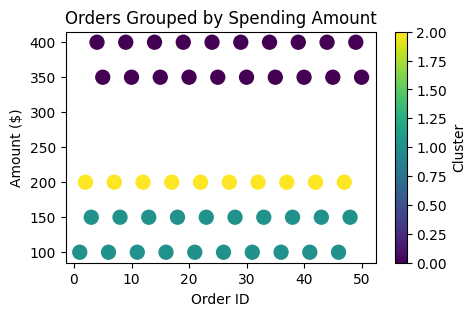

In [12]:
# Create a figure (the blank canvas)
plt.figure(figsize=(5, 3))

# Create a simple scatter plot
plt.figure(figsize=(5, 3))

# Plot all points, colored by cluster
scatter = plt.scatter(
    df['OrderID'],      # X-axis: Order ID
    df['Amount'],       # Y-axis: Amount
    c=df['Cluster'],    # Color by cluster
    cmap='viridis',     # Color scheme
   s=100               # Size of points
)

# Add labels
plt.xlabel('Order ID')
plt.ylabel('Amount ($)')
plt.title('Orders Grouped by Spending Amount')
plt.colorbar(scatter, label='Cluster')

plt.show()


---
## CREATING A BETTER VISYALIZATION 

making a more professional chart with custom colors and labels.

For cluster (0) : Red is assigned
For cluster (1): Teal is assigned
For cluster (2): Blue is assigned


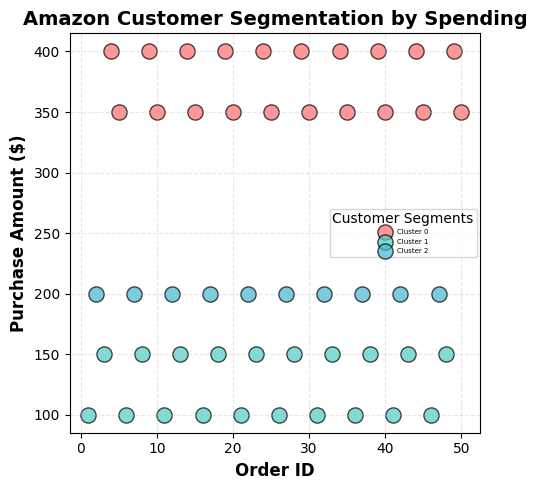

In [13]:
# Define custom colors for each cluster
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']


print("For cluster (0) : Red is assigned")
print("For cluster (1): Teal is assigned")
print("For cluster (2): Blue is assigned")



# Create the professional chart
plt.figure(figsize=(5, 5))

# Plot each cluster separately with custom colors
for cluster_num in sorted(df['Cluster'].unique()):
    # Get data for this cluster
    cluster_data = df[df['Cluster'] == cluster_num]
    
    # Plot the points
    plt.scatter(
        cluster_data['OrderID'], 
        cluster_data['Amount'],
        c=colors[cluster_num],
        label=f'Cluster {cluster_num}',
        s=120,
        alpha=0.7,
        edgecolors='black',
        linewidth=1
    )

# Add labels and title
plt.xlabel('Order ID', fontsize=12, fontweight='bold')
plt.ylabel('Purchase Amount ($)', fontsize=12, fontweight='bold')
plt.title('Amazon Customer Segmentation by Spending', fontsize=14, fontweight='bold')

# Add legend and grid
plt.legend(title='Customer Segments', loc='center right', fontsize=5)
plt.grid(True, alpha=0.3, linestyle='--')

# Show the chart
plt.tight_layout()
plt.show()


---
##  CREATING A BAR CHART FOR CLUSTER SIZES

Checking how many customers are in each cluster using a bar chart.

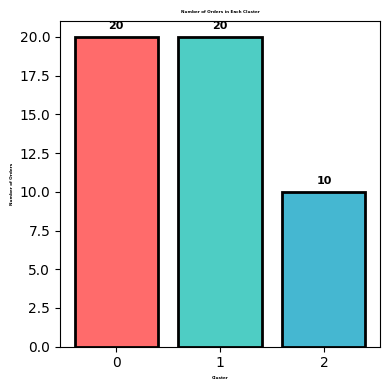

In [14]:
# Create a bar chart
plt.figure(figsize=(4, 4))

# Get cluster counts
counts = df['Cluster'].value_counts().sort_index()

# Create bar chart
bars = plt.bar(
    counts.index, 
    counts.values,
    color=colors,
    edgecolor='black',
    linewidth=2
)

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        str(count),
        ha='center',
        fontsize=8,
        fontweight='bold'
    )

plt.xlabel('Cluster', fontsize=3, fontweight='bold')
plt.ylabel('Number of Orders', fontsize=3, fontweight='bold')
plt.title('Number of Orders in Each Cluster', fontsize=3, fontweight='bold')
plt.xticks([0, 1, 2])

plt.tight_layout()
plt.show()



In [15]:
# Show the final DataFrame
print("Final DataFrame with Clusters:")
print("=" * 50)
df.head(15)

Final DataFrame with Clusters:


,OrderID,Amount,Category,Cluster
0,1,100,Electronics,1
1,2,200,Clothing,2
2,3,150,Electronics,1
3,4,400,Home,0
4,5,350,Clothing,0
5,6,100,Electronics,1
6,7,200,Clothing,2
7,8,150,Electronics,1
8,9,400,Home,0
9,10,350,Clothing,0
